In [1]:
import os, math, warnings, gc, random
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_everything(SEED)

DEVICE = torch.device('cpu')
print('Device:', DEVICE)

Device: cpu


In [2]:
# ====== CẤU HÌNH DAPT 2020 (Kaggle: sowmyamyneni/dapt2020) ======
DAPT_BASE = '/kaggle/input/datasets/sowmyamyneni/dapt2020/csv'
DAPT_CSV_PATHS = {
    1: [f'{DAPT_BASE}/enp0s3-monday.pcap_Flow.csv',
        f'{DAPT_BASE}/enp0s3-monday-pvt.pcap_Flow.csv'],
    2: [f'{DAPT_BASE}/enp0s3-public-tuesday.pcap_Flow.csv',
        f'{DAPT_BASE}/enp0s3-pvt-tuesday.pcap_Flow.csv'],
    3: [f'{DAPT_BASE}/enp0s3-public-wednesday.pcap_Flow.csv',
        f'{DAPT_BASE}/enp0s3-pvt-wednesday.pcap_Flow.csv'],
    4: [f'{DAPT_BASE}/enp0s3-public-thursday.pcap_Flow.csv',
        f'{DAPT_BASE}/enp0s3-pvt-thursday.pcap_Flow.csv'],
    5: [f'{DAPT_BASE}/enp0s3-tcpdump-friday.pcap_Flow.csv',
        f'{DAPT_BASE}/enp0s3-tcpdump-pvt-friday.pcap_Flow.csv'],
}
DAPT_LABEL_HINT = 'Stage'

# ====== MAPPING NHÃN → APT PHASE (0..4) ======
ATTACK_TO_PHASE = {
    'Benign': 0, 'benign': 0, 'BENIGN': 0, 'Normal': 0, 'normal': 0,
    'Network Scan': 1, 'NetworkScan': 1, 'network scan': 1,
    'Web vulnerability Scan': 1, 'Web Vulnerability Scan': 1,
    'WebVulnerabilityScan': 1, 'Port Scan': 1, 'PortScan': 1,
    'Reconnaissance': 1,
    'SQL injection': 2, 'SQL Injection': 2, 'SQLInjection': 2,
    'Backdoor': 2, 'backdoor': 2,
    'Malware Download': 2, 'MalwareDownload': 2,
    'Command Injection': 2, 'CommandInjection': 2,
    'CSRF': 2, 'csrf': 2,
    'Account brute force': 2, 'AccountBruteForce': 2, 'BruteForce': 2,
    'Foothold': 2,
    'DoS': 3, 'dos': 3, 'DenialOfService': 3,
    'Privilege escalation': 3, 'PrivilegeEscalation': 3,
    'Lateral Movement': 3, 'LateralMovement': 3,
    'Data Exfiltration': 4, 'DataExfiltration': 4,
    'Exfiltration': 4, 'exfiltration': 4,
}
APT_PHASE_NAMES = ['Benign', 'Reconnaissance', 'Foothold', 'Lateral Movement', 'Exfiltration']
CLASS_NAMES = APT_PHASE_NAMES          # dùng lại cho classification report / confusion matrix
N_APT_PHASES = len(APT_PHASE_NAMES)

N_PCA       = 20
N_BINS      = 32
BATCH_SIZE  = 1024
NUM_WORKERS = 0  # Windows/Jupyter: để 0; trên Kaggle Linux có thể đặt 2-4

# ====== TRAINING ======
EPOCHS       = 10
WARMUP_EPOCHS= 3
LR           = 2e-3
MIN_LR       = 1e-5
WEIGHT_DECAY = 5e-4
LABEL_SMOOTH = 0.05
FOCAL_GAMMA  = 2.0
GRAD_CLIP    = 1.0
EMA_DECAY    = 0.999
PATIENCE     = 8

# ====== MODEL ======
D_MODEL     = 128
N_HEADS     = 8
N_PERSIST   = 8
LMM_HIDDEN  = 256
N_BLOCKS    = 3
LMM_LAYERS  = 3
SWA_WINDOW  = 32
DROPOUT     = 0.15

# ====== TPA (Tensor-Product Attention) ======
R_Q = 2
R_K = 2
R_V = 2

OUTLIER_TH  = 3.0
PRE_BATCH   = 50000

for day, paths in DAPT_CSV_PATHS.items():
    for p in paths:
        print(f'  Day {day}: {os.path.basename(p)} {"OK" if os.path.exists(p) else "MISSING"}')


  Day 1: enp0s3-monday.pcap_Flow.csv OK
  Day 1: enp0s3-monday-pvt.pcap_Flow.csv OK
  Day 2: enp0s3-public-tuesday.pcap_Flow.csv OK
  Day 2: enp0s3-pvt-tuesday.pcap_Flow.csv OK
  Day 3: enp0s3-public-wednesday.pcap_Flow.csv OK
  Day 3: enp0s3-pvt-wednesday.pcap_Flow.csv OK
  Day 4: enp0s3-public-thursday.pcap_Flow.csv OK
  Day 4: enp0s3-pvt-thursday.pcap_Flow.csv OK
  Day 5: enp0s3-tcpdump-friday.pcap_Flow.csv OK
  Day 5: enp0s3-tcpdump-pvt-friday.pcap_Flow.csv OK


## 1. Load DAPT 2020 + map nhãn → APT phase + chọn feature

In [3]:
def load_real_dapt(csv_paths, attack_to_phase, label_col_hint='Stage'):
    """Load DAPT 2020 (Kaggle sowmyamyneni/dapt2020) — tự xử lý file thiếu header."""
    all_files = []
    for day, paths in csv_paths.items():
        if not isinstance(paths, list): paths = [paths]
        for path in paths:
            if os.path.exists(path):
                all_files.append((day, path))
            else:
                print(f'  [Day {day}] bỏ qua (không tìm thấy): {path}')
    if not all_files:
        raise FileNotFoundError(f'Không tìm thấy file CSV nào tại: {DAPT_BASE}')

    HDR_KEYS = ["flow id", "flow_id", "src ip", "src_ip", "protocol", "timestamp"]
    def has_header(path):
        with open(path, 'r', errors='ignore') as f:
            first = f.readline().lower()
        return any(k in first for k in HDR_KEYS)

    standard_cols = None
    for day, path in all_files:
        if has_header(path):
            standard_cols = list(pd.read_csv(path, nrows=5).columns)
            print(f'  -> Bộ cột chuẩn từ {os.path.basename(path)} ({len(standard_cols)} cột)')
            break
    if standard_cols is None:
        raise ValueError('Không tìm thấy file nào có header để lấy danh sách cột chuẩn!')

    dfs = []
    for day, path in all_files:
        hh = has_header(path)
        print(f'Loading Day {day}: {os.path.basename(path)} (header={hh}) ...')
        try:
            if hh:
                df_d = pd.read_csv(path, low_memory=False).reindex(columns=standard_cols)
            else:
                df_d = pd.read_csv(path, header=None, names=standard_cols, low_memory=False)
            df_d['Day'] = day
            dfs.append(df_d)
        except Exception as e:
            print(f'  Lỗi đọc {os.path.basename(path)}: {e}')
    if not dfs:
        raise ValueError('Không load được dataframe nào.')

    df = pd.concat(dfs, ignore_index=True)
    print('Concat shape:', df.shape)

    label_col = None
    for c in ([label_col_hint] if label_col_hint else []) + \
             ['Stage', 'stage', 'Activity', 'activity', 'Label', 'label',
              'Attack', 'attack', 'Class', 'Category']:
        if c in df.columns:
            label_col = c; break
    if label_col is None:
        raise ValueError(f'Không tìm thấy cột nhãn. Cột hiện có: {list(df.columns)}')
    print(f'Cột nhãn: "{label_col}"')

    print('\nNhãn thực tế:')
    for lbl in sorted(df[label_col].dropna().astype(str).unique()):
        print(f'  "{lbl}": {(df[label_col].astype(str)==lbl).sum():,}')

    df['APT_Phase'] = df[label_col].astype(str).map(attack_to_phase)
    unmapped = df['APT_Phase'].isna()
    if unmapped.any():
        print(f'{unmapped.sum():,} dòng chưa map → fallback theo Day')
        df.loc[unmapped, 'APT_Phase'] = df.loc[unmapped, 'Day'].map({1:0, 2:1, 3:2, 4:3, 5:4})
    df['APT_Phase'] = df['APT_Phase'].fillna(0).astype(int)

    print('\nPhase distribution:')
    for i, name in enumerate(APT_PHASE_NAMES):
        cnt = int((df['APT_Phase'] == i).sum())
        print(f'  Phase {i} ({name:<18}): {cnt:>10,} ({cnt/len(df)*100:5.1f}%)')
    return df, label_col


df, LABEL_COL = load_real_dapt(DAPT_CSV_PATHS, ATTACK_TO_PHASE, DAPT_LABEL_HINT)

# ====== Chọn feature: bỏ nhãn / Day / cột constant, chỉ giữ numeric ======
drop_cols = {'APT_Phase', 'Day', LABEL_COL, 'Label', 'label',
             'Attack', 'attack', 'Class', 'Category', 'Stage', 'stage',
             'Activity', 'activity', 'Flow ID', 'Src IP', 'Dst IP', 'Timestamp'}
std_series = df.std(numeric_only=True)
const_cols = set(std_series[std_series == 0].index.tolist())
print('Cột số constant:', sorted(const_cols))

numerical_columns = [c for c in df.columns
                     if c not in drop_cols | const_cols
                     and pd.api.types.is_numeric_dtype(df[c])]

X = df[numerical_columns].copy()
y = df['APT_Phase'].values.astype(np.int64)
print(f'X shape: {X.shape} | y shape: {y.shape} | Số lớp: {N_APT_PHASES}')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i:2d} - {name}: {int((y==i).sum()):,}')


  -> Bộ cột chuẩn từ enp0s3-monday.pcap_Flow.csv (85 cột)
Loading Day 1: enp0s3-monday.pcap_Flow.csv (header=True) ...
Loading Day 1: enp0s3-monday-pvt.pcap_Flow.csv (header=True) ...
Loading Day 2: enp0s3-public-tuesday.pcap_Flow.csv (header=True) ...
Loading Day 2: enp0s3-pvt-tuesday.pcap_Flow.csv (header=True) ...
Loading Day 3: enp0s3-public-wednesday.pcap_Flow.csv (header=True) ...
Loading Day 3: enp0s3-pvt-wednesday.pcap_Flow.csv (header=True) ...
Loading Day 4: enp0s3-public-thursday.pcap_Flow.csv (header=True) ...
Loading Day 4: enp0s3-pvt-thursday.pcap_Flow.csv (header=False) ...
Loading Day 5: enp0s3-tcpdump-friday.pcap_Flow.csv (header=True) ...
Loading Day 5: enp0s3-tcpdump-pvt-friday.pcap_Flow.csv (header=True) ...
Concat shape: (86691, 86)
Cột nhãn: "Stage"

Nhãn thực tế:
  "BENIGN": 19,454
  "Benign": 44,258
  "Data Exfiltration": 15
  "Establish Foothold": 8,604
  "Lateral Movement": 2,451
  "Reconnaissance": 11,909
8,604 dòng chưa map → fallback theo Day

Phase distrib

## 2. Split train / val / test (stratified)

In [4]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=2/3, stratify=y_tmp, random_state=SEED)
print(f'Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_te.shape}')
del X, X_tmp, y_tmp, df; gc.collect()

Train: (60683, 67) | Val: (8669, 67) | Test: (17339, 67)


0

## 3. Robust preprocessing theo batch (NaN / Inf / Outlier)

In [5]:
def robust_preprocess_large_data(X_train, X_val, X_test,
                                  batch_size=50000, outlier_threshold=3.0):
    if hasattr(X_train, 'values'): X_train = X_train.values
    if hasattr(X_val, 'values'):   X_val   = X_val.values
    if hasattr(X_test, 'values'):  X_test  = X_test.values
    X_train = X_train.astype(np.float32)
    X_val   = X_val.astype(np.float32)
    X_test  = X_test.astype(np.float32)

    sample_size = min(100000, len(X_train))
    idx = np.random.choice(len(X_train), sample_size, replace=False)
    X_sample = X_train[idx].copy()
    medians = np.nanmedian(X_sample, axis=0)
    stds    = np.nanstd(X_sample, axis=0)
    stds[stds == 0] = 1.0

    def process(batch):
        batch = batch.copy()
        batch[np.isinf(batch)] = np.nan
        for col in range(batch.shape[1]):
            cd = batch[:, col]; med = medians[col]; sd = stds[col]
            z = np.abs((cd - med) / sd)
            mask = z > outlier_threshold
            if mask.any(): batch[mask, col] = med
            nan_mask = np.isnan(batch[:, col])
            if nan_mask.any(): batch[nan_mask, col] = med
        return np.clip(batch, -1e6, 1e6)

    def by_batch(arr, name):
        n = len(arr); nb = int(np.ceil(n / batch_size)); out = []
        for i in range(nb):
            s, e = i*batch_size, min((i+1)*batch_size, n)
            out.append(process(arr[s:e]))
            if (i+1) % 20 == 0 or (i+1) == nb:
                print(f'  {name}: {e:,}/{n:,}')
        return np.vstack(out)

    Xtr = by_batch(X_train, 'train')
    Xva = by_batch(X_val,   'val  ')
    Xte = by_batch(X_test,  'test ')
    return Xtr, Xva, Xte

X_tr_p, X_val_p, X_te_p = robust_preprocess_large_data(
    X_tr, X_val, X_te, batch_size=PRE_BATCH, outlier_threshold=OUTLIER_TH)
del X_tr, X_val, X_te; gc.collect()

  train: 60,683/60,683
  val  : 8,669/8,669
  test : 17,339/17,339


0

## 4. PCA giảm chiều (40 → 20)

In [6]:
pca = PCA(n_components=N_PCA, random_state=SEED)
X_tr_pca  = pca.fit_transform(X_tr_p)
X_val_pca = pca.transform(X_val_p)
X_te_pca  = pca.transform(X_te_p)

evr = pca.explained_variance_ratio_
del X_tr_p, X_val_p, X_te_p; gc.collect()

0

## 5. StandardScaler + Tokenize bằng KBinsDiscretizer

In [7]:
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr_pca)
X_val_sc = scaler.transform(X_val_pca)
X_te_sc  = scaler.transform(X_te_pca)

kbd = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
tok_tr  = kbd.fit_transform(X_tr_sc).astype(np.int64)
tok_val = kbd.transform(X_val_sc).astype(np.int64)
tok_te  = kbd.transform(X_te_sc).astype(np.int64)

ordered_vocab = [int(max(tok_tr[:, i].max(), tok_val[:, i].max(), tok_te[:, i].max())) + 2
                 for i in range(tok_tr.shape[1])]
SEQ_LEN_FINAL = tok_tr.shape[1]
N_CLASSES = len(np.unique(y_tr))

## 6. Dataset & DataLoader

In [8]:
class TokenDS(Dataset):
    def __init__(self, X_tok, y):
        self.X = torch.from_numpy(X_tok).long()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = TokenDS(tok_tr,  y_tr)
val_ds   = TokenDS(tok_val, y_val)
test_ds  = TokenDS(tok_te,  y_te)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,
                          num_workers=NUM_WORKERS, pin_memory=(NUM_WORKERS > 0), persistent_workers=(NUM_WORKERS > 0))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(NUM_WORKERS > 0), persistent_workers=(NUM_WORKERS > 0))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(NUM_WORKERS > 0), persistent_workers=(NUM_WORKERS > 0))

## 7. Kiến trúc Titan MAG

In [9]:
class Adaptive_Weighting_Attention(nn.Module):
    def __init__(self, d_model, n_heads, d_head, R):
        super().__init__()

        assert R >= 1 and n_heads >= 1 and d_head >= 1

        self.R  = R
        self.h  = n_heads
        self.dh = d_head

        self.A = nn.Linear(d_model, R * n_heads, bias=False)
        self.B = nn.Linear(d_model, R * d_head,  bias=False)

        nn.init.xavier_uniform_(self.A.weight)
        nn.init.xavier_uniform_(self.B.weight)
        self.alpha = nn.Parameter(torch.ones(R, n_heads))

    def forward(self, x):                        
        B, L, _ = x.shape

        a = self.A(x).view(B, L, self.R, self.h)    
        b = self.B(x).view(B, L, self.R, self.dh) 

        a = a * self.alpha.view(1, 1, self.R, self.h)

        out = torch.einsum('blrh,blrd->blhd', a, b) / float(self.R)

        return out                                   


class FeatureEmbedding(nn.Module):
    def __init__(self, vocab_sizes, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(v, d_model) for v in vocab_sizes])
        self.pos  = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        B, L = x.shape
        out = torch.stack([self.embs[i](x[:, i]) for i in range(L)], dim=1)
        out = out + self.pos[:, :L]
        return self.drop(self.norm(out))


class DimReduceBlock(nn.Module):
    def __init__(self, d_model, latent_dim=None, dropout=0.1):
        super().__init__()
        if latent_dim is None: latent_dim = d_model // 2
        self.encoder = nn.Sequential(nn.Linear(d_model, latent_dim), nn.GELU(), nn.Dropout(dropout))
        self.decoder = nn.Sequential(nn.Linear(latent_dim, d_model), nn.GELU(), nn.Dropout(dropout))
        self.norm    = nn.LayerNorm(d_model)
    def forward(self, x):
        return self.norm(x + self.decoder(self.encoder(x)))


class HiddenMLP(nn.Module):
    def __init__(self, d_model, expansion=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_model * expansion), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * expansion, d_model), nn.Dropout(dropout),
        )
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):
        return self.norm(x + self.net(x))


class NeuralLongTermMemory(nn.Module):
    def __init__(self, d_model, hidden=256, n_layers=3, dropout=0.1):
        super().__init__()
        layers = []
        in_dim = d_model
        for _ in range(n_layers - 1):
            layers += [nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout)]
            in_dim = hidden
        layers.append(nn.Linear(in_dim, d_model))
        self.M = nn.Sequential(*layers)

        self.key       = nn.Linear(d_model, d_model)
        self.value     = nn.Linear(d_model, d_model)
        self.query     = nn.Linear(d_model, d_model)
        self.alpha_net = nn.Linear(d_model, 1)
        self.eta_net   = nn.Linear(d_model, 1)
        self.theta_net = nn.Linear(d_model, 1)
        self.out_norm  = nn.LayerNorm(d_model)

    def forward(self, h):
        B, L, D = h.shape
        k = self.key(h); v = self.value(h); q = self.query(h)
        alpha = torch.sigmoid(self.alpha_net(h))
        eta   = torch.sigmoid(self.eta_net(h))
        theta = torch.sigmoid(self.theta_net(h)) * 0.1
        Mt = torch.zeros(B, D, device=h.device)
        St = torch.zeros(B, D, device=h.device)
        outs = []
        for t in range(L):
            kt, vt, qt = k[:, t], v[:, t], q[:, t]
            v_hat = self.M(kt) + Mt
            grad  = 2.0 * (v_hat - vt)
            St = eta[:, t] * St - theta[:, t] * grad
            Mt = (1 - alpha[:, t]) * Mt + St
            outs.append(self.M(qt) + Mt)
        return self.out_norm(torch.stack(outs, dim=1))


class TPASlidingWindowAttention(nn.Module):
    def __init__(self, d_model, n_heads, R_Q=2, R_K=2, R_V=2, window=32, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d, self.h = d_model, n_heads
        self.dh = d_model // n_heads
        self.q_proj = Adaptive_Weighting_Attention(d_model, n_heads, self.dh, R_Q)
        self.k_proj = Adaptive_Weighting_Attention(d_model, n_heads, self.dh, R_K)
        self.v_proj = Adaptive_Weighting_Attention(d_model, n_heads, self.dh, R_V)
        self.proj   = nn.Linear(d_model, d_model)
        self.norm   = nn.LayerNorm(d_model)
        self.drop   = nn.Dropout(dropout)
        self.window = window

    def _to_heads(self, t):     
        return t.permute(0, 2, 1, 3).contiguous()

    def forward(self, x):
        B, L, D = x.shape
        q = self._to_heads(self.q_proj(x))
        k = self._to_heads(self.k_proj(x))
        v = self._to_heads(self.v_proj(x))
        idx  = torch.arange(L, device=x.device)
        diff = idx.unsqueeze(0) - idx.unsqueeze(1)
        block = (diff > 0) | (diff < -(self.window - 1))
        attn_mask = torch.where(block,
                                torch.tensor(float('-inf'), device=x.device),
                                torch.tensor(0.0, device=x.device))
        y = F.scaled_dot_product_attention(q, k, v, attn_mask=attn_mask, is_causal=False)
        y = y.transpose(1, 2).contiguous().reshape(B, L, D)
        return self.norm(x + self.drop(self.proj(y)))


class TitanBlock(nn.Module):
    def __init__(self, d_model, n_heads, lmm_hidden, swa_window,
                 lmm_layers, R_Q, R_K, R_V, dropout=0.1):
        super().__init__()
        self.dim_reduce = DimReduceBlock(d_model, dropout=dropout)
        self.hidden_mlp = HiddenMLP(d_model, expansion=4, dropout=dropout)
        self.stm        = TPASlidingWindowAttention(d_model, n_heads,
                                                    R_Q, R_K, R_V,
                                                    window=swa_window, dropout=dropout)
        self.lmm        = NeuralLongTermMemory(d_model, hidden=lmm_hidden,
                                               n_layers=lmm_layers, dropout=dropout)
        self.combine    = nn.Linear(d_model * 2, d_model)
        self.gate_proj  = nn.Linear(d_model, d_model)
        self.gate_norm  = nn.LayerNorm(d_model)
        self.drop       = nn.Dropout(dropout)

    def forward(self, x):
        h = self.dim_reduce(x)
        h = self.hidden_mlp(h)
        y_swa = self.stm(h)
        y_lmm = self.lmm(h)
        merged = self.combine(torch.cat([y_swa, y_lmm], dim=-1))
        out = self.gate_norm(merged * torch.sigmoid(self.gate_proj(h)))
        return x + self.drop(out)


class TitanMAG(nn.Module):
    def __init__(self, vocab_sizes, n_classes, d_model=128, n_heads=8,
                 n_persist=8, lmm_hidden=256, swa_window=32, lmm_layers=3,
                 n_blocks=3, R_Q=2, R_K=2, R_V=2, dropout=0.15,
                 seq_len_max=512):
        super().__init__()
        self.embed      = FeatureEmbedding(vocab_sizes, d_model,
                                           max_len=seq_len_max, dropout=dropout)
        self.persistent = nn.Parameter(torch.randn(1, n_persist, d_model) * 0.02)
        self.blocks     = nn.ModuleList([
            TitanBlock(d_model, n_heads, lmm_hidden, swa_window,
                       lmm_layers, R_Q, R_K, R_V, dropout=dropout)
            for _ in range(n_blocks)
        ])
        self.n_persist = n_persist
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x):
        B = x.size(0)
        h = self.embed(x)
        persist = self.persistent.expand(B, -1, -1)
        h = torch.cat([persist, h], dim=1)
        for blk in self.blocks:
            h = blk(h)
        h = h[:, self.n_persist:]
        pooled = h.mean(dim=1)
        return self.head(pooled)


model = TitanMAG(ordered_vocab, N_CLASSES,
                 d_model=D_MODEL, n_heads=N_HEADS,
                 n_persist=N_PERSIST, lmm_hidden=LMM_HIDDEN,
                 swa_window=SWA_WINDOW, lmm_layers=LMM_LAYERS,
                 n_blocks=N_BLOCKS,
                 R_Q=R_Q, R_K=R_K, R_V=R_V,
                 dropout=DROPOUT,
                 seq_len_max=SEQ_LEN_FINAL + N_PERSIST).to(DEVICE)
awa_alphas = [(n, p.shape) for n, p in model.named_parameters() if 'alpha' in n and 'net' not in n]



## 8. Train

In [10]:
import copy as _copy

class FocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.ls    = label_smoothing
        self.register_buffer('w', class_weights if class_weights is not None else torch.tensor([]))
    def forward(self, logits, target):
        w = self.w if self.w.numel() > 0 else None
        ce = F.cross_entropy(logits, target, weight=w,
                             label_smoothing=self.ls, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

_cnt = np.bincount(y_tr, minlength=N_CLASSES).astype(np.float64)
_cnt[_cnt == 0] = 1.0
_w   = _cnt.sum() / (N_CLASSES * _cnt)
_w   = np.clip(_w / _w.mean(), 0.25, 10.0)
class_weights = torch.tensor(_w, dtype=torch.float32, device=DEVICE)

criterion = FocalLoss(class_weights=class_weights,
                      gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTH).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                              weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999))

steps_per_epoch = max(1, len(train_loader))
total_steps     = EPOCHS * steps_per_epoch
warmup_steps    = WARMUP_EPOCHS * steps_per_epoch

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / max(1, warmup_steps)
    prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(MIN_LR / LR, 0.5 * (1 + math.cos(math.pi * prog)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()
                       if v.dtype.is_floating_point}
    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
    def apply_to(self, model):
        self.backup = {k: v.detach().clone() for k, v in model.state_dict().items()
                       if k in self.shadow}
        sd = model.state_dict()
        for k in self.shadow: sd[k].copy_(self.shadow[k])
    def restore(self, model):
        sd = model.state_dict()
        for k, v in self.backup.items(): sd[k].copy_(v)
        self.backup = {}

ema = EMA(model, decay=EMA_DECAY)

def evaluate(model, loader):
    model.eval(); all_p, all_t = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            all_p.append(model(xb).argmax(-1).cpu().numpy())
            all_t.append(yb.numpy())
    p = np.concatenate(all_p); t = np.concatenate(all_t)
    return {
        'acc':     accuracy_score(t, p),
        'f1':      f1_score(t, p, average='weighted', zero_division=0),
        'f1_macro':f1_score(t, p, average='macro',    zero_division=0),
        'prec':    precision_score(t, p, average='weighted', zero_division=0),
        'rec':     recall_score(t, p, average='weighted',    zero_division=0),
        'pred': p, 'true': t,
    }

history = []
best_f1 = -1.0
best_state = None
patience_left = PATIENCE

for epoch in range(1, EPOCHS + 1):
    model.train(); losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        ema.update(model)
        losses.append(loss.item())

    ema.apply_to(model)
    m = evaluate(model, val_loader)
    ema.restore(model)

    history.append({'epoch': epoch, 'loss': float(np.mean(losses)),
                    **{k: m[k] for k in ['acc','f1','f1_macro','prec','rec']}})
    cur_lr = optimizer.param_groups[0]['lr']
    print(f'[Epoch {epoch:2d}/{EPOCHS}] lr={cur_lr:.2e} | loss={np.mean(losses):.4f} | acc={m["acc"]:.4f} | f1={m["f1"]:.4f} | prec={m["prec"]:.4f} | rec={m["rec"]:.4f}.')


    if m['f1_macro'] > best_f1 + 1e-4:
        best_f1 = m['f1_macro']
        ema.apply_to(model)
        best_state = _copy.deepcopy(model.state_dict())
        ema.restore(model)
        patience_left = PATIENCE
    else:
        patience_left -= 1
        if patience_left <= 0:
            print(f' Early stopping tại epoch {epoch} (best macro-F1={best_f1:.4f})')
            break

if best_state is not None:
    model.load_state_dict(best_state)

[Epoch  1/10] lr=6.78e-04 | loss=0.0433 | acc=0.0525 | f1=0.0664 | prec=0.7710 | rec=0.0525.
[Epoch  2/10] lr=1.34e-03 | loss=0.0202 | acc=0.4148 | f1=0.5171 | prec=0.7180 | rec=0.4148.
[Epoch  3/10] lr=2.00e-03 | loss=0.0175 | acc=0.7101 | f1=0.6584 | prec=0.7695 | rec=0.7101.
[Epoch  4/10] lr=1.90e-03 | loss=0.0160 | acc=0.7504 | f1=0.6757 | prec=0.7505 | rec=0.7504.
[Epoch  5/10] lr=1.62e-03 | loss=0.0150 | acc=0.7771 | f1=0.7215 | prec=0.7698 | rec=0.7771.
[Epoch  6/10] lr=1.22e-03 | loss=0.0139 | acc=0.8154 | f1=0.7808 | prec=0.8229 | rec=0.8154.
[Epoch  7/10] lr=7.77e-04 | loss=0.0132 | acc=0.8541 | f1=0.8379 | prec=0.8575 | rec=0.8541.
[Epoch  8/10] lr=3.77e-04 | loss=0.0126 | acc=0.8819 | f1=0.8747 | prec=0.8872 | rec=0.8819.
[Epoch  9/10] lr=9.90e-05 | loss=0.0120 | acc=0.8963 | f1=0.8935 | prec=0.9029 | rec=0.8963.
[Epoch 10/10] lr=1.00e-05 | loss=0.0117 | acc=0.9018 | f1=0.9012 | prec=0.9106 | rec=0.9018.


## 9. Đánh giá trên tập TEST + Confusion Matrix


===== FINAL TEST METRICS (Multi-class) =====
Accuracy        : 0.9014
F1 (weighted)   : 0.9010
F1 (macro)      : 0.6447
Precision (w)   : 0.9098
Recall (w)      : 0.9014

----- Classification Report -----
                  precision    recall  f1-score   support

          Benign     0.9298    0.9662    0.9477     12743
  Reconnaissance     0.8194    0.6268    0.7103      2382
        Foothold     0.8697    0.9238    0.8959      1719
Lateral Movement     0.9791    0.4776    0.6420       490
    Exfiltration     0.0142    0.6000    0.0278         5

        accuracy                         0.9014     17339
       macro avg     0.7224    0.7189    0.6447     17339
    weighted avg     0.9098    0.9014    0.9010     17339



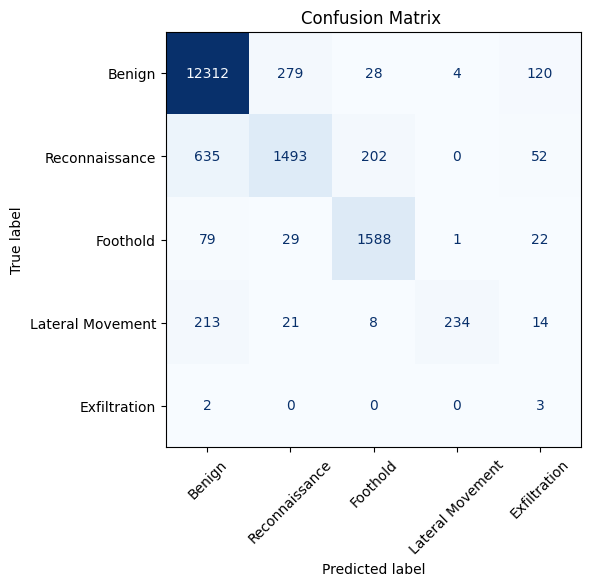

In [11]:
m = evaluate(model, test_loader)
print('\n===== FINAL TEST METRICS (Multi-class) =====')
print(f'Accuracy        : {m["acc"]:.4f}')
print(f'F1 (weighted)   : {m["f1"]:.4f}')
print(f'F1 (macro)      : {m["f1_macro"]:.4f}')
print(f'Precision (w)   : {m["prec"]:.4f}')
print(f'Recall (w)      : {m["rec"]:.4f}')

print('\n----- Classification Report -----')
print(classification_report(m['true'], m['pred'],
                            target_names=CLASS_NAMES, zero_division=0, digits=4))

labels_idx = list(range(len(CLASS_NAMES)))
cm = confusion_matrix(m['true'], m['pred'], labels=labels_idx)
size = max(6, len(CLASS_NAMES) * 0.6)
fig, ax = plt.subplots(figsize=(size, size))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
plt.title('Confusion Matrix ')
plt.tight_layout(); plt.show()